In [1]:
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(parent_dir)
print(os.getcwd())

/local0/home/mfilo/git/CRN-GenerativeAI/applications_modular/molecular_oscillators_frequencies_3species_ppo


In [2]:
# Import general packages
from openpyxl import Workbook, load_workbook
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.ppo_agent import PPOAgent
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex
from RL4CRN.value_functions.state_value_function import StateValueFunction

# Import Inteface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import oscillation_error

In [3]:
# Set the logger to use Comet
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
api_key = "o77J6VCMDamustkfJuMXZ2jdV"
logger = CometLogger(
    api_key=api_key,
    project="Molecular_Oscillators_freq_PPO",        
    workspace="maurice-filo", 
    name=f'Transients_Experiment_{timestamp}',
)
logger = logger.experiment

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maurice-filo/molecular-oscillators-freq-ppo/d55d579d04eb429cb0dbd7d4466115d9



In [4]:
# Construct the template CRN
r1 = MassAction(reactant_labels=[], product_labels=['X_1'], input_channels=['u_1'], params=[1.], params_controllability=[True])
r2 = MassAction(reactant_labels=['X_1'], product_labels=[], input_channels=[None], params=[0.1], params_controllability=[True])
r3 = MassAction(reactant_labels=['X_2'], product_labels=[], input_channels=[None], params=[0.1], params_controllability=[True])
r4 = MassAction(reactant_labels=['X_3'], product_labels=[], input_channels=[None], params=[0.1], params_controllability=[True])
crn_template = IOCRN([r1, r2, r3, r4], output_labels=['X_3'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
species_labels = ['X_1', 'X_2', 'X_3']
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
Library of possible reactions:
Number of reactions: 91
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> X_2;  [MAK(None)]
R3: ∅ ----> X_3;  [MAK(None)]
R4: ∅ ----> X_1 + X_1;  [MAK(None)]
R5: ∅ ----> X_1 + X_2;  [MAK(None)]
R6: ∅ ----> X_1 + X_3;  [MAK(None)]
R7: ∅ ----> X_2 + X_2;  [MAK(None)]
R8: ∅ ----> X_2 + X_3;  [MAK(None)]
R9: ∅ ----> X_3 + X_3;  [MAK(None)]
R10: X_1 ----> ∅;  [MAK(None)]
R11: X_1 ----> X_2;  [MAK(None)]
R12: X_1 ----> X_3;  [MAK(None)]
R13: X_1 ----> X_1 + X_1;  [MAK(None)]
R14: X_1 ----> X_1 + X_2;  [MAK(None)]
R15: X_1 ----> X_1 + X_3;  [MAK(None)]
R16: X_1 ----> X_2 + X_2;  [MAK(None)]
R17: X_1 ----> X_2 + X_3;  [MAK(None)]
R18: X_1 ----> X_3 + X_3;  [MAK(None)]
R19: X_2 ----> ∅;  [MAK(None)]
R20: X_2 ----> X_1;  [MAK(None)]
R21: X_2 ----> X_3;  [M

In [5]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [6]:
# Flags and filenames
save_flag = True                                               # Save the agent checkpoint
load_flag = False                                               # Load the agent checkpoint 
train_flag = True                                               # Train the agent
save_sheet_flag = True                                          # Save the configuration to an Excel sheet

save_filename = timestamp + '.pth'                              # Filename for saving the agent checkpoint
load_filename = ''                                              # Filename for loading the agent checkpoint
file_name = "Discover_Molecular_Oscillators_Freq_PPO.xlsx"           # Filename for saving the Excel sheet

In [7]:
# Hyperparameters
max_added_reactions = 6                             # Maximum number of reactions
N_CPUs = os.cpu_count()                             # Number of CPUs          
N = 30*N_CPUs                                       # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-4                                # Learning rate for the optimizer 
hall_of_fame_size = 10                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters
    'entropy_weight': 0.0001, 
    'entropy_update_coefficient': 0.75, 
    'entropy_schedule': 10000, 
    'minimum_entropy_weight': 0.0001
}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.99, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 20
}
epoch_num = 200                                    # Number of epochs for training
render_schedule = 1                                 # Render every # of epochs
mode = {                                            # Mode of the experiment
    'style': 'logger', 
    'task': 'transients', 
    'format': 'image'
}
ppo_parameters = {
    'eps': 0.2, 
    'value_loss_weight': 0.1, 
    'gamma': 1, 
    'lam': 0.95, 
    'update_policy_every': 5
}

# Time horizon for the simulation
t_f = 200                                           # Final time for the simulation
N_t = 1000                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
periods = [10, 15, 20]
u_list = [np.array([1/p]) for p in periods]

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0., 0., 0.]])

# Weight on the damping metric and initial time for peak detection
w = [4/10, 1/10, 5/10]
t0 = 50.

# Construct the compute reward routine
def compute_reward(state):
    f_list = u_list
    x0_list = ic.get_ic(state)
    return oscillation_error(state, u_list, x0_list, time_horizon, f_list, w, t0, LARGE_NUMBER=1e4)

In [8]:
# Save the experiment discription in an Excel sheet TODO: Update for PPO
if save_sheet_flag:
    sheet_name = "Data"
    headers = ["Timestamp", "URL", 
               "Maximum Number of Added Reactions", 
               "Number of Species", 
               "Number of Inputs", 
               "Batch Size", 
               "Allow Input Influence", 
               "Learning Rate", "Number of Epochs", "Neural Network Depth", "Neural Network Width", "Deep Layer Size", "Number of CPUs",
               "Initial Entropy Weight", "Entropy Update Coefficient", "Entropy Schedule", "Minimum Entropy Weight", 
               "Risk", "Risk Update", "Maximum Risk", "Risk Schedule",
               "Render Schedule", "Hall of Fame Size", 
               "Simulation Time", "Number of Time Steps", "Initial Condition Scenarios", "Input Scenarios", 
               "epsilon", "Value Loss Weight", "Gamma", "Lambda", "Update Policy Every"]
    data_row = [timestamp, logger.url, 
                max_added_reactions, 
                len(species_labels), 
                p, N,
                allow_input_influence, 
                learning_rate, epoch_num, depth, width, deep_layer_size, N_CPUs, 
                entropy_scheduler['entropy_weight'], entropy_scheduler['entropy_update_coefficient'], entropy_scheduler['entropy_schedule'], entropy_scheduler['minimum_entropy_weight'],
                risk_scheduler['risk'], risk_scheduler['risk_update'], risk_scheduler['max_risk'], risk_scheduler['risk_schedule'],
                render_schedule, hall_of_fame_size,
                t_f, N_t, len(ic.values), len(u_list), 
                ppo_parameters['eps'], ppo_parameters['value_loss_weight'], ppo_parameters['gamma'], ppo_parameters['lam'], ppo_parameters['update_policy_every']]

    if os.path.exists(file_name):
        wb = load_workbook(file_name)
        if sheet_name in wb.sheetnames:
            ws = wb[sheet_name]
        else:
            ws = wb.create_sheet(sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    if ws.max_column < 2:
        for i, header in enumerate(headers, start=1):
            ws.cell(row=i, column=1, value=header)
    next_col = ws.max_column + 1
    for i, value in enumerate(data_row, start=1):
        ws.cell(row=i, column=next_col, value=value)

    wb.save(file_name)
    print(f"New experiment data saved in column {next_col} of '{file_name}'.")

New experiment data saved in column 2 of 'Discover_Molecular_Oscillators_Freq_PPO.xlsx'.


In [9]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [10]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=False, masks=masks, device=device)

# Construct the state value function
output_head_attributes = {"hidden_size": width, "num_layers": depth}
state_value_function = StateValueFunction(M, K, p, encoder_attributes, deep_layer_size, output_head_attributes, device=device)

# Construct the Agent
agent = PPOAgent(policy, state_value_function, ppo_parameters, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, device=device)
if load_flag:
    agent.policy.load_state_dict(torch.load(save_filename, map_location=device)) #TODO: Update for PPO - state value function also needs to be loaded

In [11]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [12]:
# Training Loop
if train_flag:
    for i in tqdm(range(epoch_num)):
        mult_env.reset()
        for j in range(max_added_reactions):
            observations = mult_env.observe(observer, tensorizer)
            actions = agent.act(observations, actuator)
            out = mult_env.step(actions, stepper)
        agent.states_sequence.append(observations) 
        rewards = mult_env.get_reward(compute_reward)
        agent.update(rewards, step_iteration=i)
        if i % render_schedule == 0:
            mult_env.render(rewards, n_best=1, disregarded_percentage=0.9, mode=mode)

100%|██████████| 200/200 [1:06:44<00:00, 20.02s/it]


In [13]:
# Test the model
mult_env.reset()
for j in range(max_added_reactions):
    observations = mult_env.observe(observer, tensorizer)
    actions = agent.act(observations, actuator)
    out = mult_env.step(actions, stepper)
rewards = mult_env.get_reward(compute_reward)

# Gather the CRNs from the environments
crns = mult_env.gather()

# Sort the CRNs by rewards
sorted_crns_rewards = sorted(zip(crns, rewards), key=lambda x: x[1])

IOCRN 0, Reward: 0.10043767190788977
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_2 ----> X_2 + X_2;  [MAK(2.8053197860717773)]
X_1 + X_1 ----> X_2 + X_3;  [MAK(1.9891048669815063)]
X_2 + X_3 ----> X_1 + X_1;  [MAK(2.467245101928711)]
X_1 ----> X_2 + X_2;  [MAK(0.8592495322227478)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(0.7914425730705261)]
X_2 ----> X_1 + X_2;  [MAK(0.7710750699043274)]
IOCRN 1, Reward: 0.10159590836038823
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_2 ----> X_2 + X_2;  [MAK(2.8053197860717773)]
X_1 + X_1 ----> X_2 + X_3;  [MAK(1.9891048669815063)]
X_2 + X_3 ----> X_1 + X_1;  [MAK(2.467245101928711)]
X_1 ----> X_2 + X_2;  [MAK(0.8592495322227478)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(0.7914425730705261)]
X_2 --

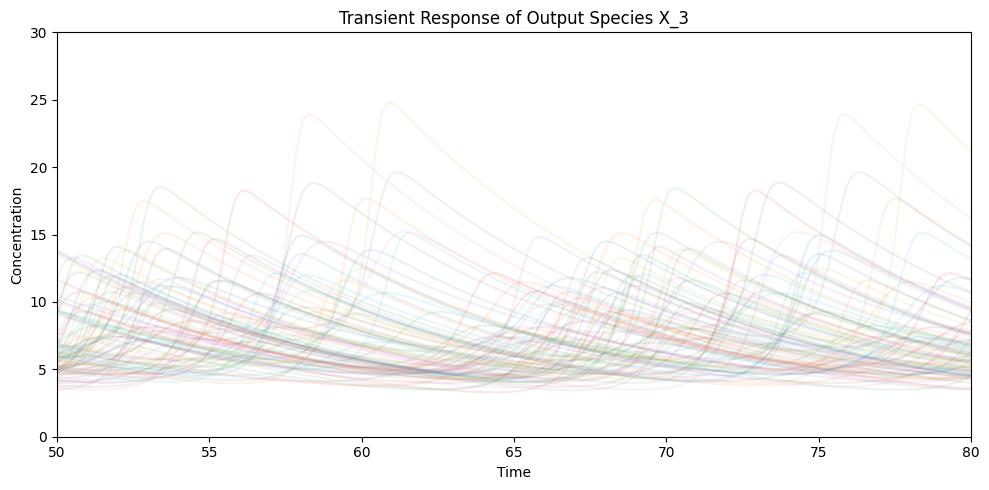

In [19]:
# Plot the results
n_plot = 30
ax = None
for i in range(n_plot):
    x0_list = ic.get_ic(sorted_crns_rewards[i][0])
    time_horizon, x_list, y_list, last_task_info = sorted_crns_rewards[i][0].transient_response(u_list, x0_list, time_horizon)
    fig, ax = sorted_crns_rewards[i][0].plot_transient_response(axes=ax)
    ax[0].set_ylim([0, 30])
    ax[0].set_xlim([50, 80])
    print(f"IOCRN {i}, Reward: {sorted_crns_rewards[i][1]}")
    print(sorted_crns_rewards[0][0])

In [15]:
if save_flag:
    torch.save(agent.policy.state_dict(), save_filename)